# 1 实验

不存在一套适用于所有问题的最优试验设计方案。实际上，最优试验设计会随研究目标与响应曲面（输入输出关系）类型的变化而改变。图 1.4 展示了若干基于一维函数的示例。举例而言，若目标是近似拟合响应曲面：当响应曲面起伏较大时，采用均匀填充样本空间的设计方案效果较好（图 1.4 左上子图）；而当函数曲线平滑时，在边界附近布置更多样本点的设计方案更为合适（右上子图）。倘若目标是求取函数最大值，则应在全局最大值附近布置更多设计点（左下子图）。与之相对，若研究目标为不确定性传递（$X$ 不确定，探究 $Y=f(X)$ 的不确定性是怎么受 $X$ 传递的），设计点的布置方式需要贴合输入量的分布特征（右下子图，图中曲线代表输入量的概率密度）。

设粗糙函数为 $$y=\frac{\sin(10\pi x)}{1+64(x-0.5)^2}$$ 则取点应均匀；设光滑函数为 $$y=\frac{1}{1+64(x-0.5)^2}$$ 则取点应向两边聚集，选用 $Beta(0.5,0.5)$ 分布中的均匀点；设被优化的函数为 $$y=\frac23f_{Beta(2,10)}(x)+\frac13f_{Beta(2,10)}(x)$$ 则取点应向最大值聚集，选用 $Beta(2,10)$ 分布中的均匀点；设被探究不确定性的函数仍为 $$y=\frac23f_{Beta(2,10)}(x)+\frac13f_{Beta(2,10)}(x)$$ 则取点应分别向两处极值聚集，使用R包support中的sp对函数 $y$ 选取支撑点（最能代表函数走向的点）。

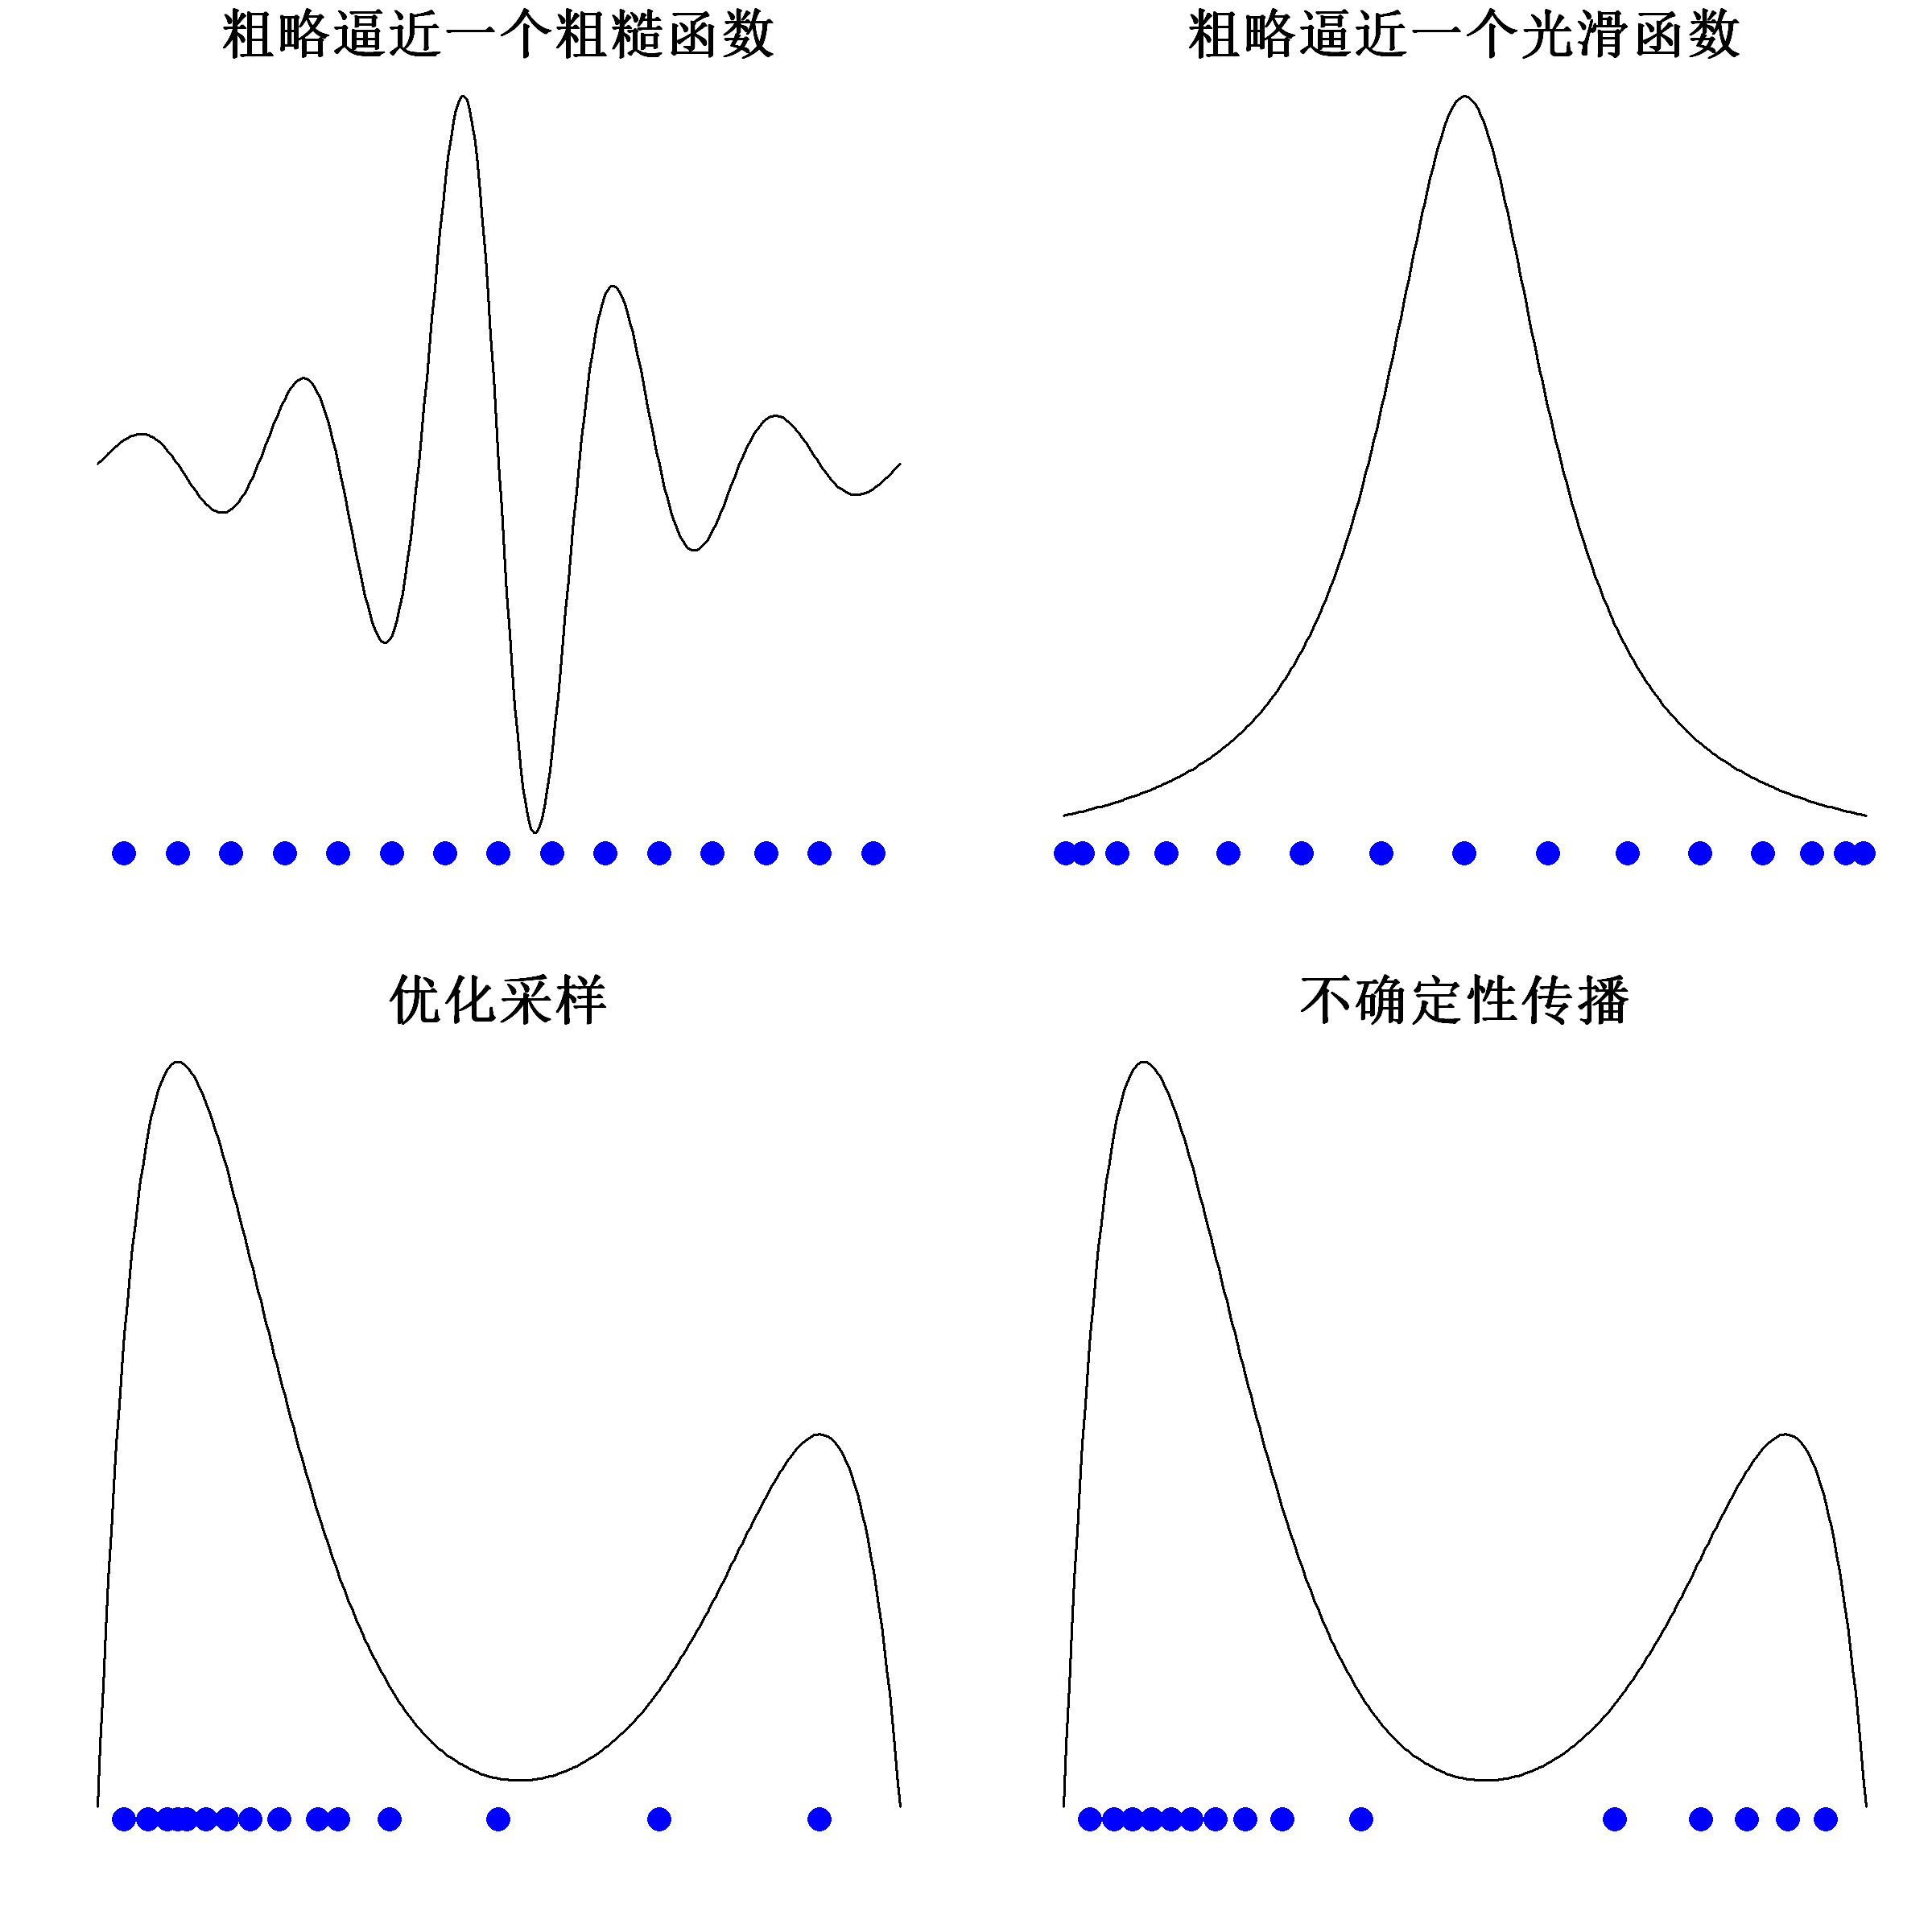

In [ ]:
# 图 1.4

options(repr.plot.width=20,repr.plot.height=20)
par(mfrow=c(2,2))
x=seq(0,1,length=301)
y=sin(10*pi*x)/(1+64*(x-.5)^2)
plot(x,y,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y)-.05,max(y)),main="粗略逼近一个粗糙函数",cex.main=4)
n=15
D=((1:n)-.5)/n
points(cbind(D,min(y)-.05),pch=16,cex=4,col="blue")

y=1/(1+64*(x-.5)^2)
plot(x,y,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y)-.05,max(y)),main="粗略逼近一个光滑函数",cex.main=4)
D=qbeta(((1:n)-.5)/n,.5,.5)
points(cbind(D,min(y)-.05),pch=16,cex=4,col="blue")

y=2/3*dbeta(x,2,10)+1/3*dbeta(x,10,2)
plot(x,y,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y)-.05,max(y)),main="优化采样",cex.main=4)
n1=n*2/3
n2=n/3
D0=((1:n2)-.5)/n2
D=c(D0,qbeta(((1:n1)-.5)/n1,2,10))
points(cbind(D,min(y)-.05),pch=16,cex=4,col="blue")

y=2/3*dbeta(x,2,10)+1/3*dbeta(x,10,2)
plot(x,y,type="l",axes=FALSE,xlab="",ylab="",lwd=3,ylim=c(min(y)-.05,max(y)),main="不确定性传播",cex.main=4)
set.seed(1)
x=c(rbeta(1000*n1,2,10),rbeta(1000*n2,10,2))
library(support)
D=sp(n,1,dist.samp=cbind(x))$sp
points(cbind(D,min(y)-.05),pch=16,cex=4,col="blue")
par(mfrow=c(1,1))

设 $\boldsymbol{x} = (x_1, \dots, x_p)'$ 为 $p$ 个输入变量（也称为影响因子），$y$ 为输出变量（或称响应值）。假设统计模型：$$y = h(\boldsymbol{x}) + \epsilon\tag{1.1}$$ 式中 $h(\boldsymbol{x})$ 代表输入输出关系（响应曲面），$\epsilon$ 为随机误差，通常假定 $\epsilon \sim \mathcal{N}(0, \sigma^2)$，其中 $\sigma^2$ 为随机误差的方差。假设我们开展一项单因素试验，该因素设置两个取值（也称为水平）：$x=0$ 和 $x=1$，每种水平设置 3 次重复试验。试验数据如图 1.5 中蓝色实心圆点所示。设 $h(\cdot)$ 为图中黑色实线代表的函数，试验人员并不知晓该函数形式。假设我们采用模型 $y_i = \beta_0 + \beta_1x_i + \epsilon_i$ 拟合数据，其中对 $i=1,\dots,n$（本例中 $n=6$），$\epsilon_i$ 独立同分布，服从正态分布 $\mathcal{N}(0, \sigma^2)$。拟合得到的直线以及 95% 置信区间展示在图的左侧子图，高斯过程的拟合结果同样展示在该图的右侧子图。

设要拟合的函数为 $$y=\frac{\sin(10\pi x)}{1+64(x-0.25)^2}+x^2$$

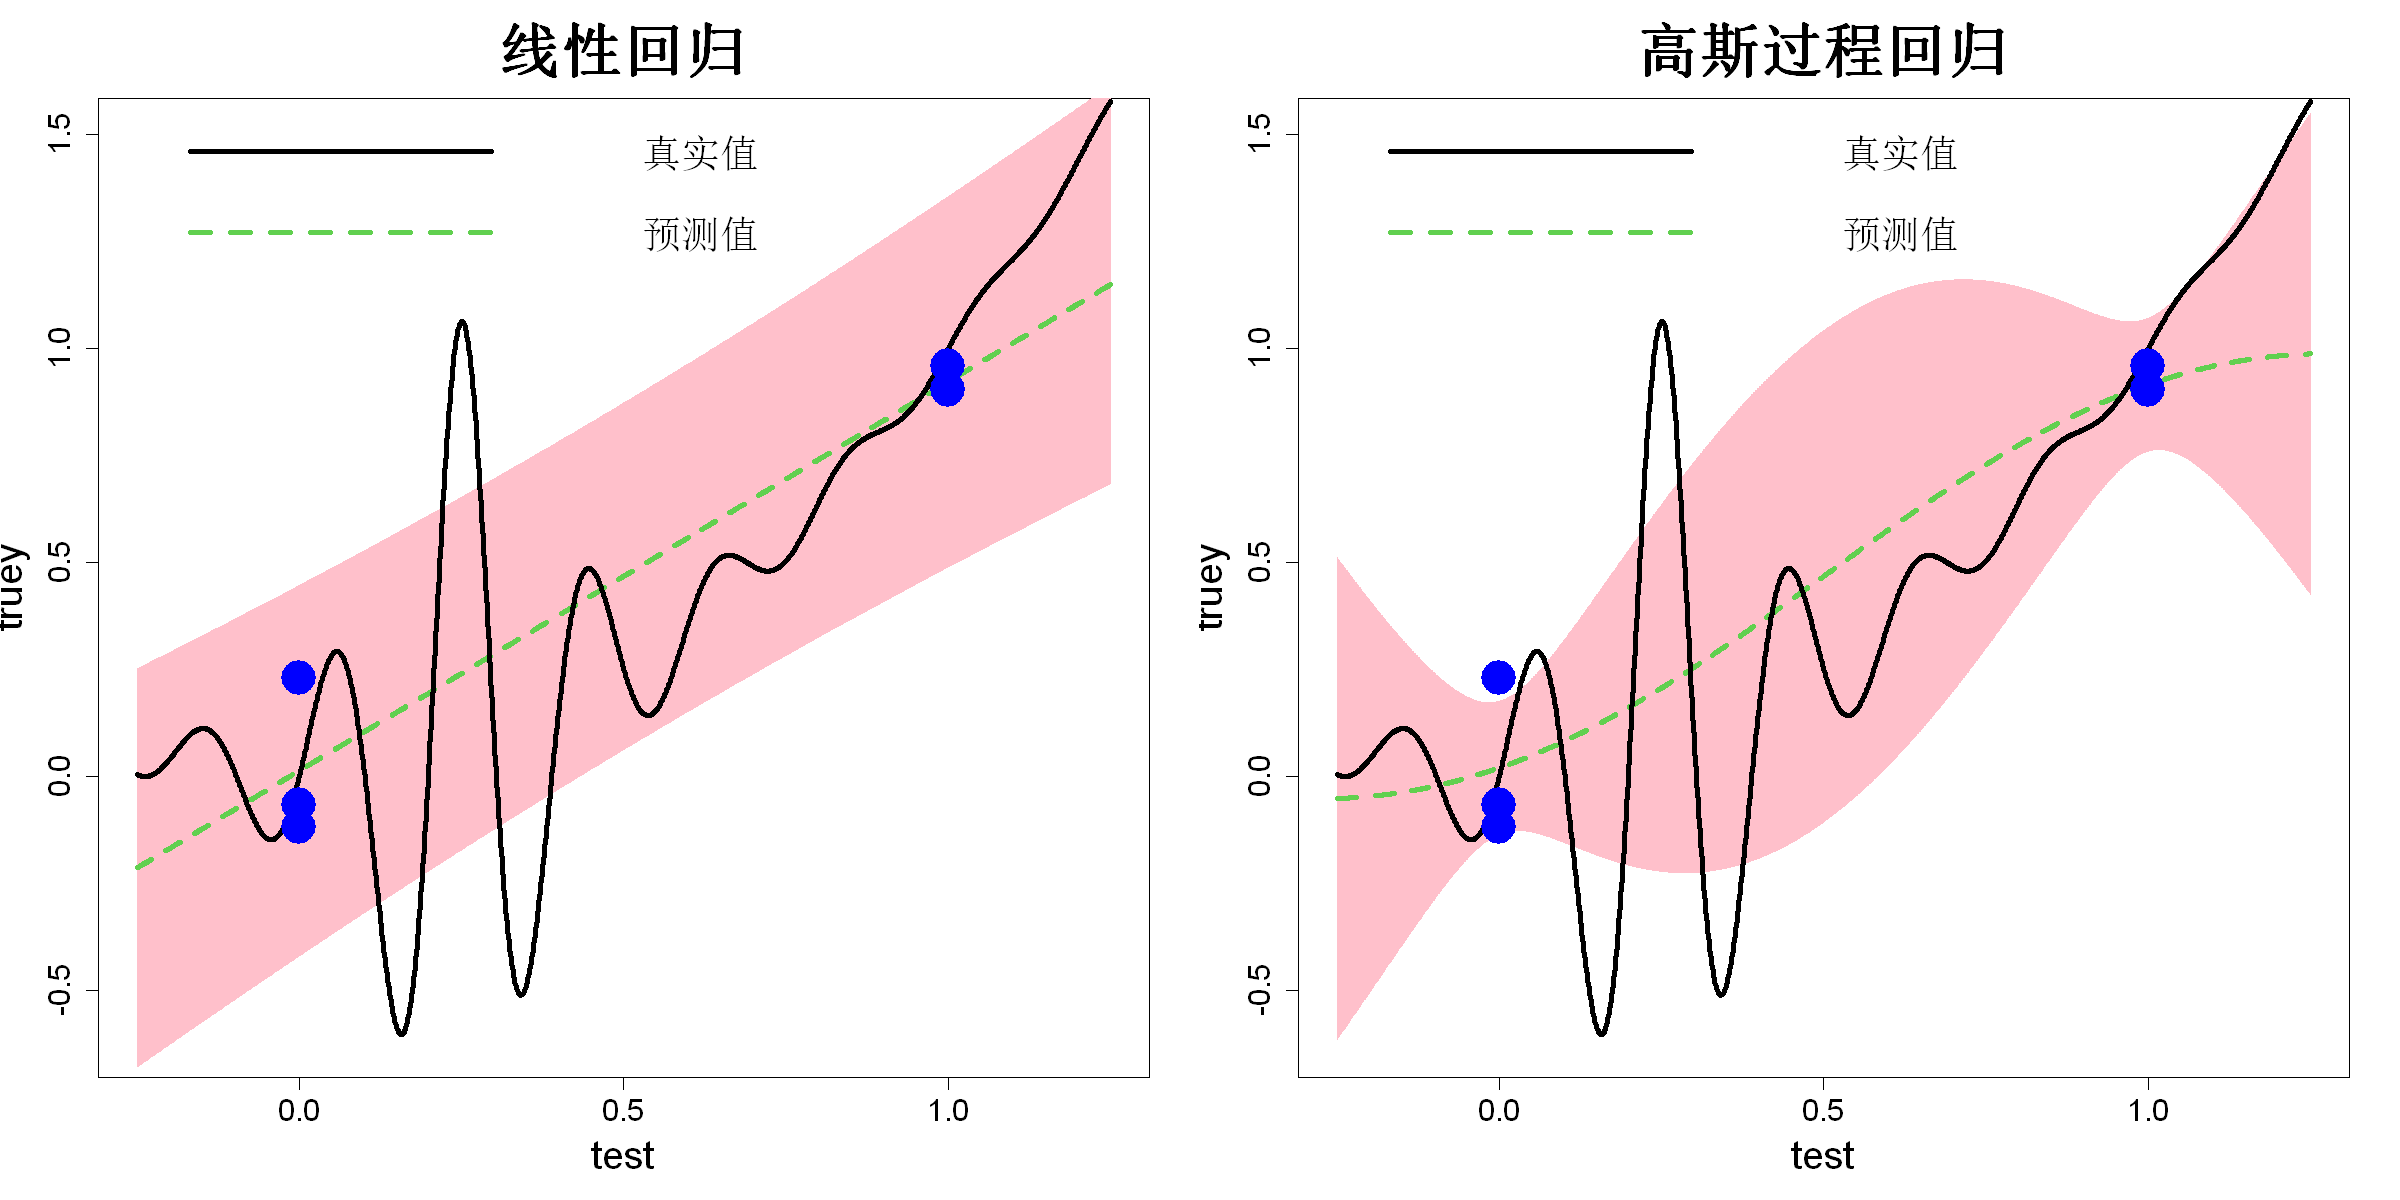

In [ ]:
# 图 1.5

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
n=6
x=rep(c(0,1),c(n/2,n/2))
f=function(x)sin(10*pi*x)/(1+64*(x-.25)^2)+x^2
set.seed(7)
y=f(x)+.1*rnorm(n)
l=-.25
u=1.25
test=seq(l,u,.001)
truey=f(test)

a.lm=lm(y~x)
pred=predict.lm(a.lm,newdata=data.frame(x=test),interval="prediction")
plot(test,truey,type="n",xlim=c(l,u),ylim=c(min(y)-.5,1.5),main="线性回归",cex.main=3,cex.axis=1.5,cex.lab=2)
low=pred[,2]
up=pred[,3]
polygon(c(test,rev(test)),c(low,rev(up)),col="pink",border="pink")
lines(test,pred[,1],col=3,lwd=4,lty=2)
lines(test,truey,lwd=4)
points(x,y,pch=16,cex=4,col="blue")
legend(-.4,1.65,legend=c("真实值","预测值"),lty=c(1,2),col=c(1,3),lwd=c(4,4),bty="n",cex=2)

library(rkriging)
a.gp=Fit.Kriging(x,y,interpolation=FALSE,fit=TRUE,model="OK",kernel.parameters=list(type="Gaussian"))
pred=Predict.Kriging(a.gp,data.frame(x=test))
plot(test,truey,type="n",xlim=c(l,u),ylim=c(min(y)-.5,1.5),main="高斯过程回归",cex.main=3,cex.axis=1.5,cex.lab=2)
low=pred$mean-2*pred$sd
up=pred$mean+2*pred$sd
polygon(c(test,rev(test)),c(low,rev(up)),col="pink",border="pink")
lines(test,pred$mean,col=3,lwd=4,lty=2)
lines(test,truey,lwd=4)
points(x,y,pch=16,col="blue",cex=4)
legend(-.4,1.65,legend=c("真实值","预测值"),lty=c(1,2),col=c(1,3),lwd=c(4,4),bty="n",cex=2)
par(mfrow=c(1,1))

线性回归的预测不确定性包含参数估计（$\hat{\beta}_0$ 和 $\hat{\beta}_1$）带来的不确定性以及随机误差（$\epsilon$）。该模型在取值端点处（$x=0$ 和 $x=1$）不确定性最大，在中点位置（$x=0.5$）不确定性最小。与之不同，高斯过程回归属于非参数回归方法，因此其预测不确定性包含关于函数 $h(\cdot)$ 的不确定性与随机误差。在已有观测数据的位置，它的不确定性最低，而在区间中点处不确定性达到峰值，这与线性回归的特征恰好相反！

当因子数量（$p$）较多，而实验次数（$n$）较少时，高斯过程回归在边界处同样会产生较大不确定性，该现象与线性回归所得结论一致。因此，采用线性回归框架或高斯过程回归框架大概率会得到相同结果。不过，若依托线性回归框架开展研究，会对最优设计的探索带来一定局限。